# Mental Health in Tech Survey — EDA

Data Science Term Project

## 1. Setup and Data Loading

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Korean font (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 100

# Create outputs folder
os.makedirs('../outputs', exist_ok=True)

# Load data
df = pd.read_csv('survey.csv')
print(f"Data loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Data loaded: 1,259 rows x 27 columns


## 2. Basic Inspection

In [20]:
# Dataset shape
print(f"Shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print(f"Number of records: {df.shape[0]:,}")

Shape: (1259, 27)
Number of features: 27
Number of records: 1,259


In [21]:
# Column info: dtypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

In [22]:
# First 5 rows
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [23]:
# Summary statistics for numerical features
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [24]:
# Summary statistics for categorical features
df.describe(include='object').T

,count,unique,top,freq
Timestamp,1259,1246,2014-08-27 12:31:41,2
Gender,1259,49,Male,615
Country,1259,48,United States,751
state,744,45,CA,138
self_employed,1241,2,No,1095
family_history,1259,2,No,767
treatment,1259,2,Yes,637
work_interfere,995,4,Sometimes,465
no_employees,1259,6,6-25,290
remote_work,1259,2,No,883


## 3. Missing Values Analysis

In [25]:
# Count and percentage of missing values
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing

,missing_count,missing_pct
comments,1095,86.97
state,515,40.91
work_interfere,264,20.97
self_employed,18,1.43


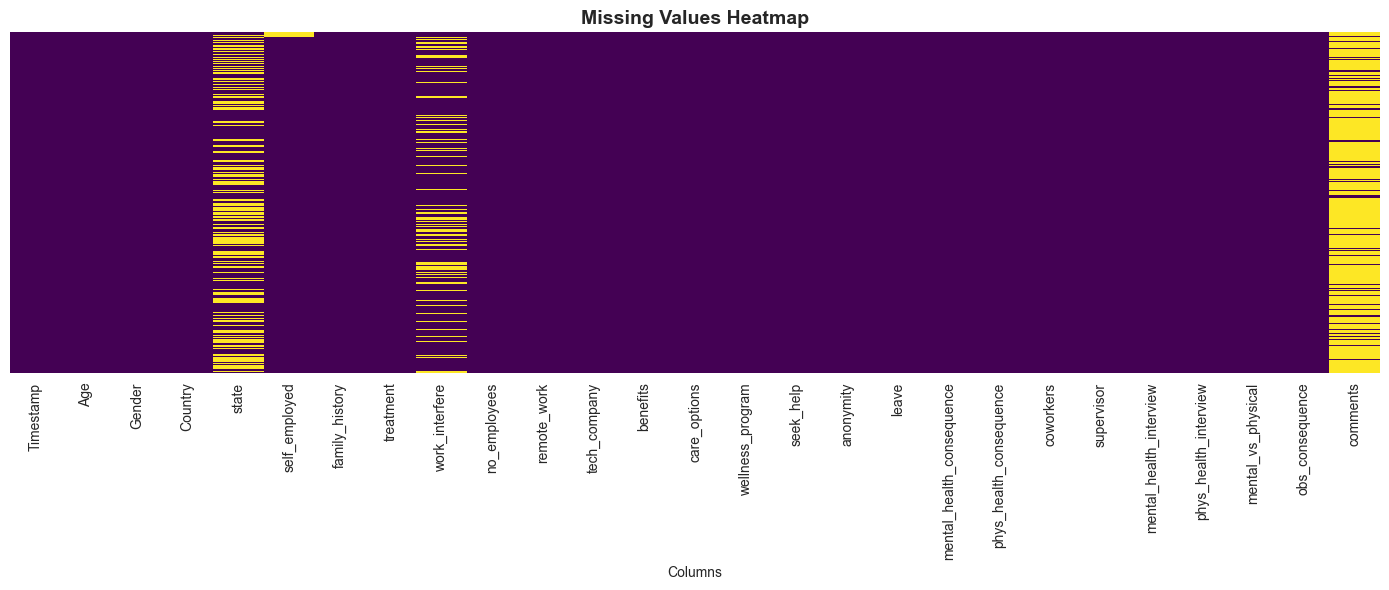

In [26]:
# Missing values heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.tight_layout()
plt.savefig('../outputs/missing_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

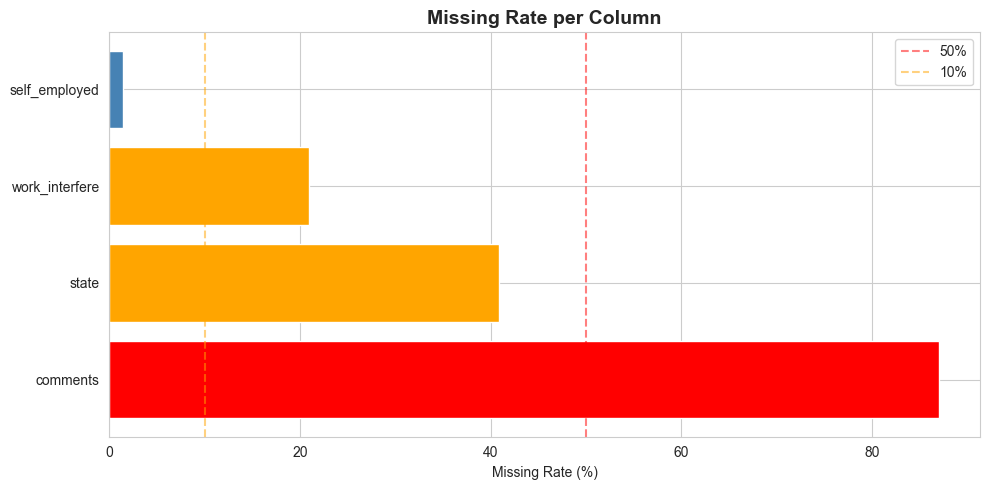

In [27]:
# Missing rate bar plot with threshold markers
if len(missing) > 0:
    plt.figure(figsize=(10, 5))
    colors = ['red' if x > 50 else 'orange' if x > 10 else 'steelblue'
              for x in missing['missing_pct']]
    plt.barh(missing.index, missing['missing_pct'], color=colors)
    plt.xlabel('Missing Rate (%)')
    plt.title('Missing Rate per Column', fontsize=14, fontweight='bold')
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
    plt.axvline(x=10, color='orange', linestyle='--', alpha=0.5, label='10%')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../outputs/missing_barplot.png', dpi=100, bbox_inches='tight')
    plt.show()

## 4. Target Variable: `treatment`

In [28]:
# Target distribution
target_counts = df['treatment'].value_counts()
print(target_counts)
print(f"\nYes: {target_counts['Yes']/len(df)*100:.1f}%")
print(f"No:  {target_counts['No']/len(df)*100:.1f}%")

treatment
Yes    637
No     622
Name: count, dtype: int64

Yes: 50.6%
No:  49.4%


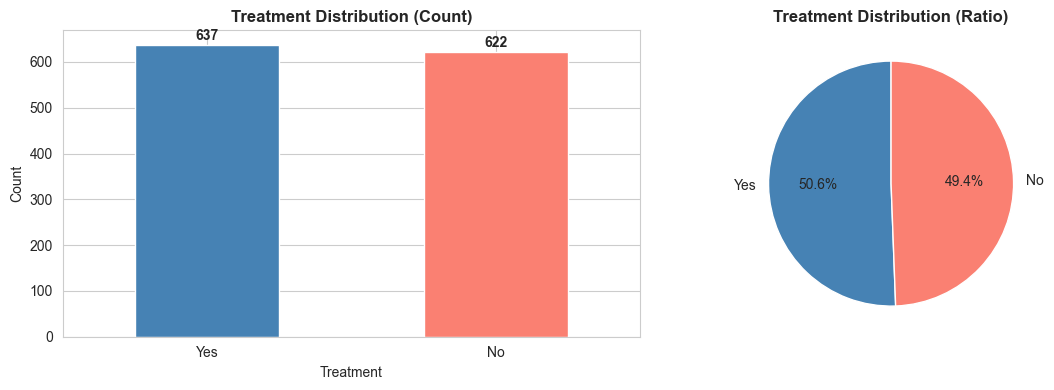

In [29]:
# Target distribution visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
target_counts.plot(kind='bar', ax=ax[0], color=['steelblue', 'salmon'])
ax[0].set_title('Treatment Distribution (Count)', fontweight='bold')
ax[0].set_xlabel('Treatment')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(target_counts):
    ax[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
          colors=['steelblue', 'salmon'], startangle=90)
ax[1].set_title('Treatment Distribution (Ratio)', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Numerical Feature: `Age`

In [30]:
# Age basic stats and outlier counts
print(df['Age'].describe())
print(f"\nNegative age:      {(df['Age'] < 0).sum()}")
print(f"Age below 5:       {(df['Age'] < 5).sum()}")
print(f"Age above 100:     {(df['Age'] > 100).sum()}")

count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64

Negative age:      3
Age below 5:       3
Age above 100:     2


In [31]:
# Outlier candidates (Age < 18 or > 80)
print("Outlier candidates:")
print(df.loc[(df['Age'] < 18) | (df['Age'] > 80), 'Age'].sort_values().values)

Outlier candidates:
[      -1726         -29          -1           5           8          11
         329 99999999999]


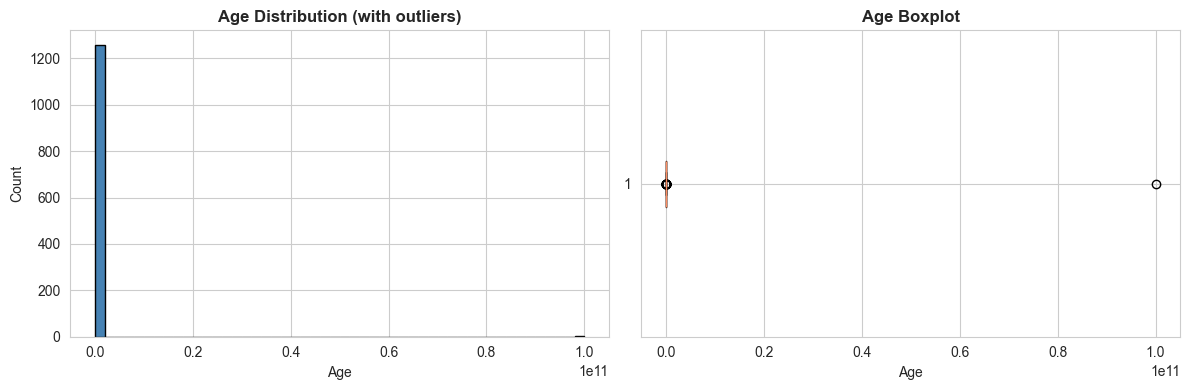

In [32]:
# Age distribution with outliers (histogram + boxplot)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df['Age'], bins=50, color='steelblue', edgecolor='black')
ax[0].set_title('Age Distribution (with outliers)', fontweight='bold')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Count')

ax[1].boxplot(df['Age'].dropna(), vert=False)
ax[1].set_title('Age Boxplot', fontweight='bold')
ax[1].set_xlabel('Age')

plt.tight_layout()
plt.savefig('../outputs/age_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

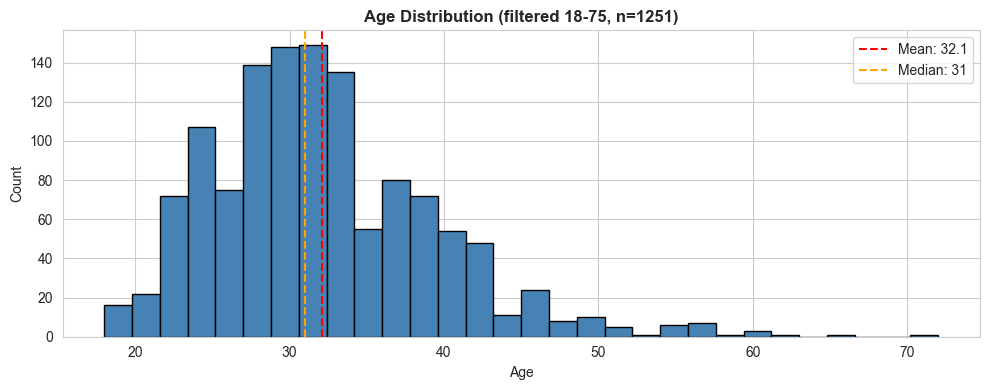

In [33]:
# Age distribution after filtering to reasonable range (18-75)
reasonable_age = df[(df['Age'] >= 18) & (df['Age'] <= 75)]['Age']

plt.figure(figsize=(10, 4))
plt.hist(reasonable_age, bins=30, color='steelblue', edgecolor='black')
plt.title(f'Age Distribution (filtered 18-75, n={len(reasonable_age)})', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.axvline(reasonable_age.mean(), color='red', linestyle='--',
            label=f'Mean: {reasonable_age.mean():.1f}')
plt.axvline(reasonable_age.median(), color='orange', linestyle='--',
            label=f'Median: {reasonable_age.median():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/age_filtered.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Categorical Features

### 6-1. `Gender` (most messy variable)

In [34]:
# Show all unique values of Gender
print(f"Number of unique Gender values: {df['Gender'].nunique()}\n")
print("Gender distribution:")
print(df['Gender'].value_counts())

Number of unique Gender values: 49

Gender distribution:
Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Woman                                               3
Male                                                3
Cis Male                                            2
Female                                              2
Man                                                 2
Female (trans)                                      2
Male-ish                                            1
maile                                               1
Trans-female      

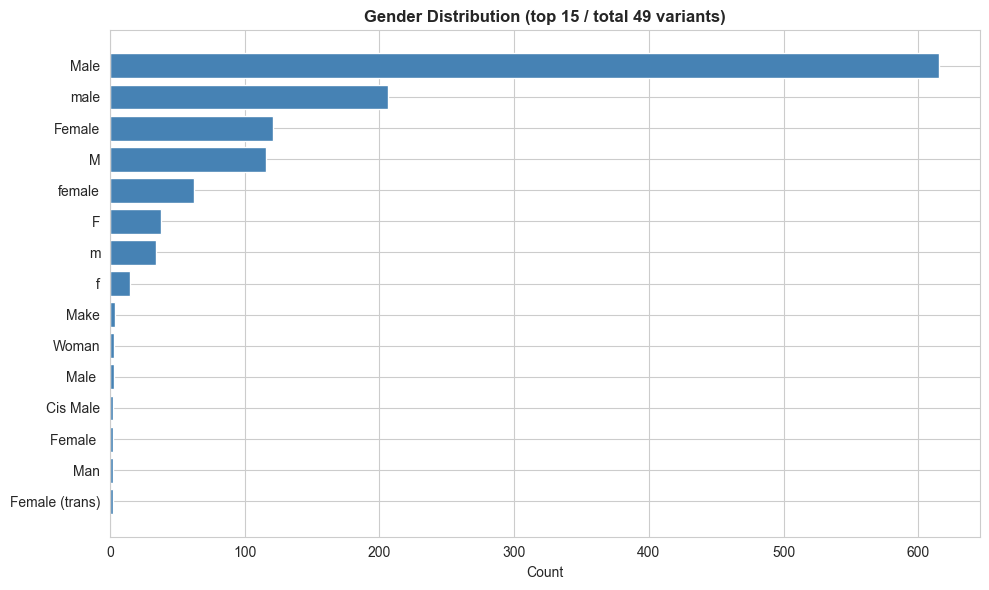

In [35]:
# Top 15 Gender values visualization
plt.figure(figsize=(10, 6))
gender_counts = df['Gender'].value_counts().head(15)
plt.barh(gender_counts.index[::-1], gender_counts.values[::-1], color='steelblue')
plt.title(f'Gender Distribution (top 15 / total {df["Gender"].nunique()} variants)',
          fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('../outputs/gender_messy.png', dpi=100, bbox_inches='tight')
plt.show()

### 6-2. `Country` (highly imbalanced)

In [36]:
# Country distribution stats
print(f"Total countries: {df['Country'].nunique()}")
print(f"\nTop 10:")
print(df['Country'].value_counts().head(10))
print(f"\nCountries with <=3 respondents: {(df['Country'].value_counts() <= 3).sum()}")

Total countries: 48

Top 10:
Country
United States     751
United Kingdom    185
Canada             72
Germany            45
Netherlands        27
Ireland            27
Australia          21
France             13
India              10
New Zealand         8
Name: count, dtype: int64

Countries with <=3 respondents: 28


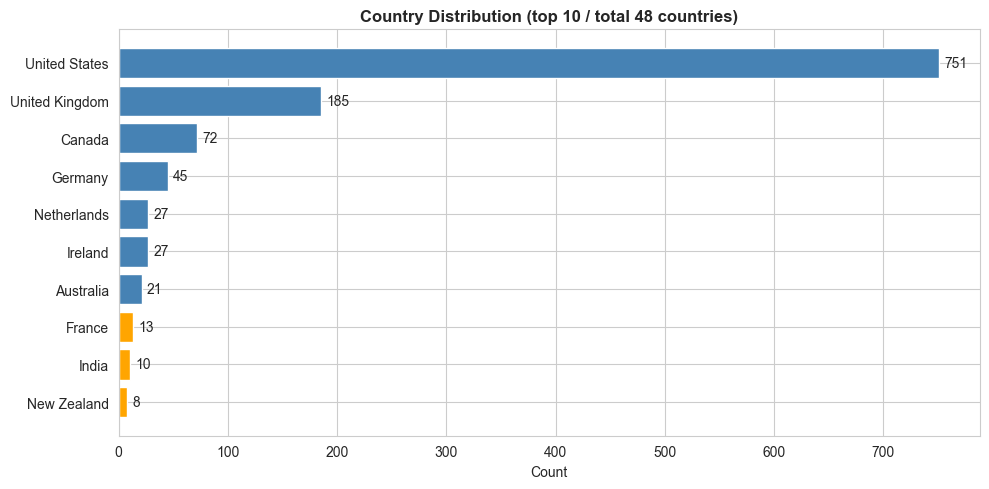

In [37]:
# Country top 10 visualization
plt.figure(figsize=(10, 5))
top_countries = df['Country'].value_counts().head(10)
colors_c = ['steelblue' if c >= 20 else 'orange' for c in top_countries.values]
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color=colors_c[::-1])
plt.title(f'Country Distribution (top 10 / total {df["Country"].nunique()} countries)',
          fontweight='bold')
plt.xlabel('Count')
for i, v in enumerate(top_countries.values[::-1]):
    plt.text(v + 5, i, str(v), va='center')
plt.tight_layout()
plt.savefig('../outputs/country_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

### 6-3. Other categorical features by meaning group

In [38]:
# Group columns by semantic meaning
groups = {
    'Company Info': ['no_employees', 'remote_work', 'tech_company'],
    'Mental Health Policy': ['benefits', 'care_options', 'wellness_program',
                              'seek_help', 'anonymity', 'leave', 'mental_vs_physical'],
    'Workplace Atmosphere': ['mental_health_consequence', 'phys_health_consequence',
                              'coworkers', 'supervisor', 'mental_health_interview',
                              'phys_health_interview', 'obs_consequence'],
    'Personal Background': ['self_employed', 'family_history', 'work_interfere']
}

for group_name, cols in groups.items():
    print(f"\n{'='*60}")
    print(f"[{group_name}]")
    print(f"{'='*60}")
    for col in cols:
        if col in df.columns:
            print(f"\n>> {col} (unique: {df[col].nunique()})")
            print(df[col].value_counts(dropna=False).to_string())


[Company Info]

>> no_employees (unique: 6)
no_employees
6-25              290
26-100            289
More than 1000    282
100-500           176
1-5               162
500-1000           60

>> remote_work (unique: 2)
remote_work
No     883
Yes    376

>> tech_company (unique: 2)
tech_company
Yes    1031
No      228

[Mental Health Policy]

>> benefits (unique: 3)
benefits
Yes           477
Don't know    408
No            374

>> care_options (unique: 3)
care_options
No          501
Yes         444
Not sure    314

>> wellness_program (unique: 3)
wellness_program
No            842
Yes           229
Don't know    188

>> seek_help (unique: 3)
seek_help
No            646
Don't know    363
Yes           250

>> anonymity (unique: 3)
anonymity
Don't know    819
Yes           375
No             65

>> leave (unique: 5)
leave
Don't know            563
Somewhat easy         266
Very easy             206
Somewhat difficult    126
Very difficult         98

>> mental_vs_physical (unique: 3)
men

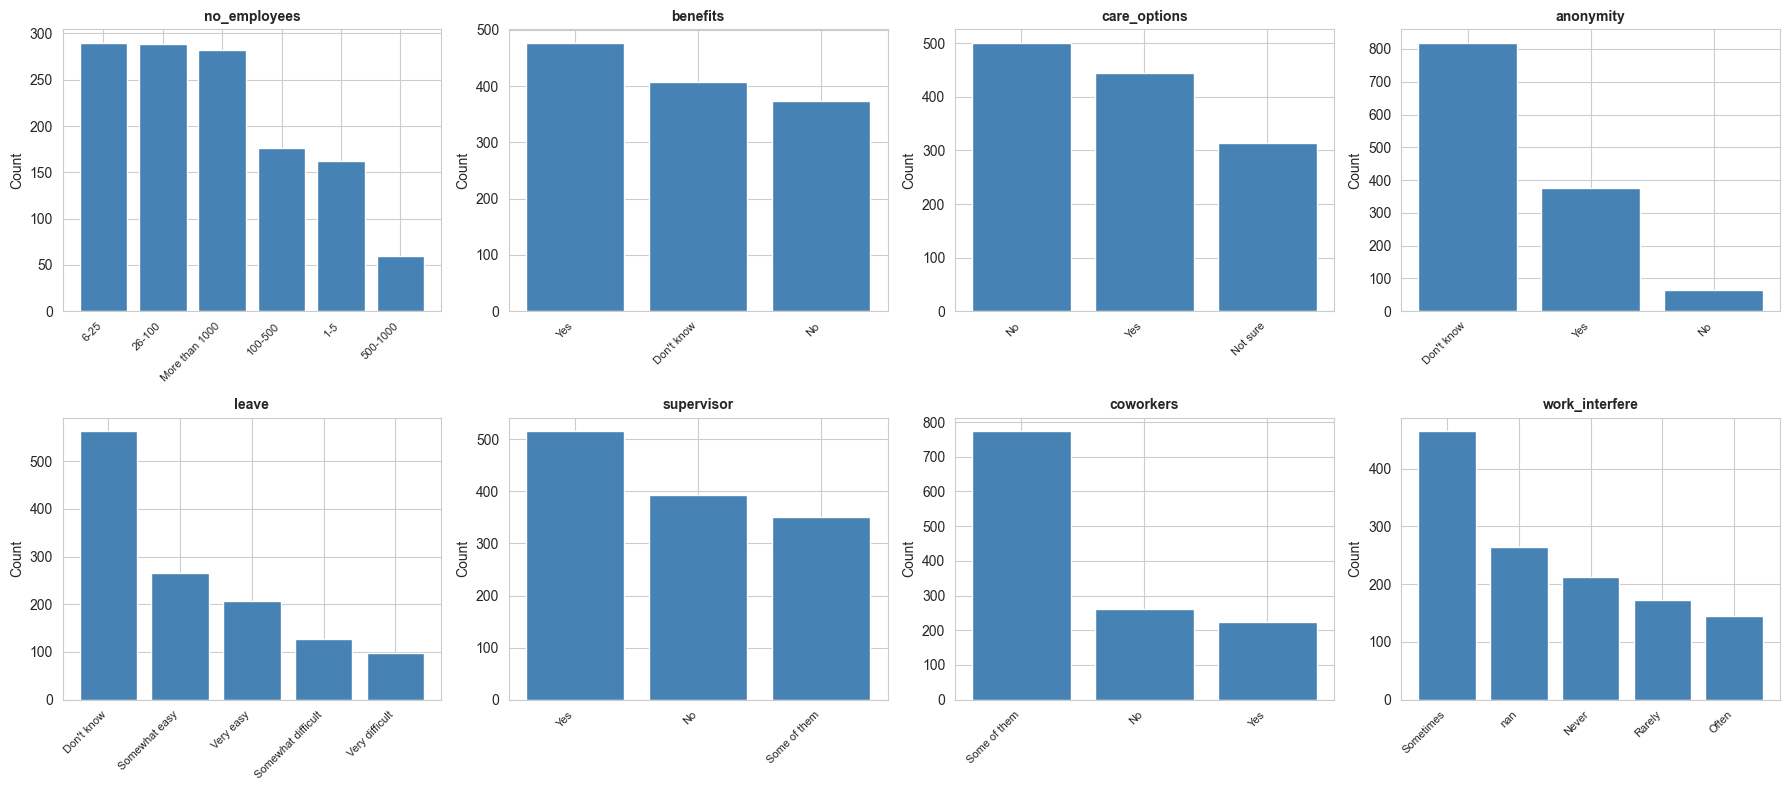

In [39]:
# Key categorical variables overview
key_vars = ['no_employees', 'benefits', 'care_options', 'anonymity',
            'leave', 'supervisor', 'coworkers', 'work_interfere']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_vars):
    counts = df[col].value_counts(dropna=False)
    axes[i].bar(range(len(counts)), counts.values, color='steelblue')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/categorical_overview.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Target vs Key Features (Story Evidence)

### 7-1. Mental Health Policy vs Treatment

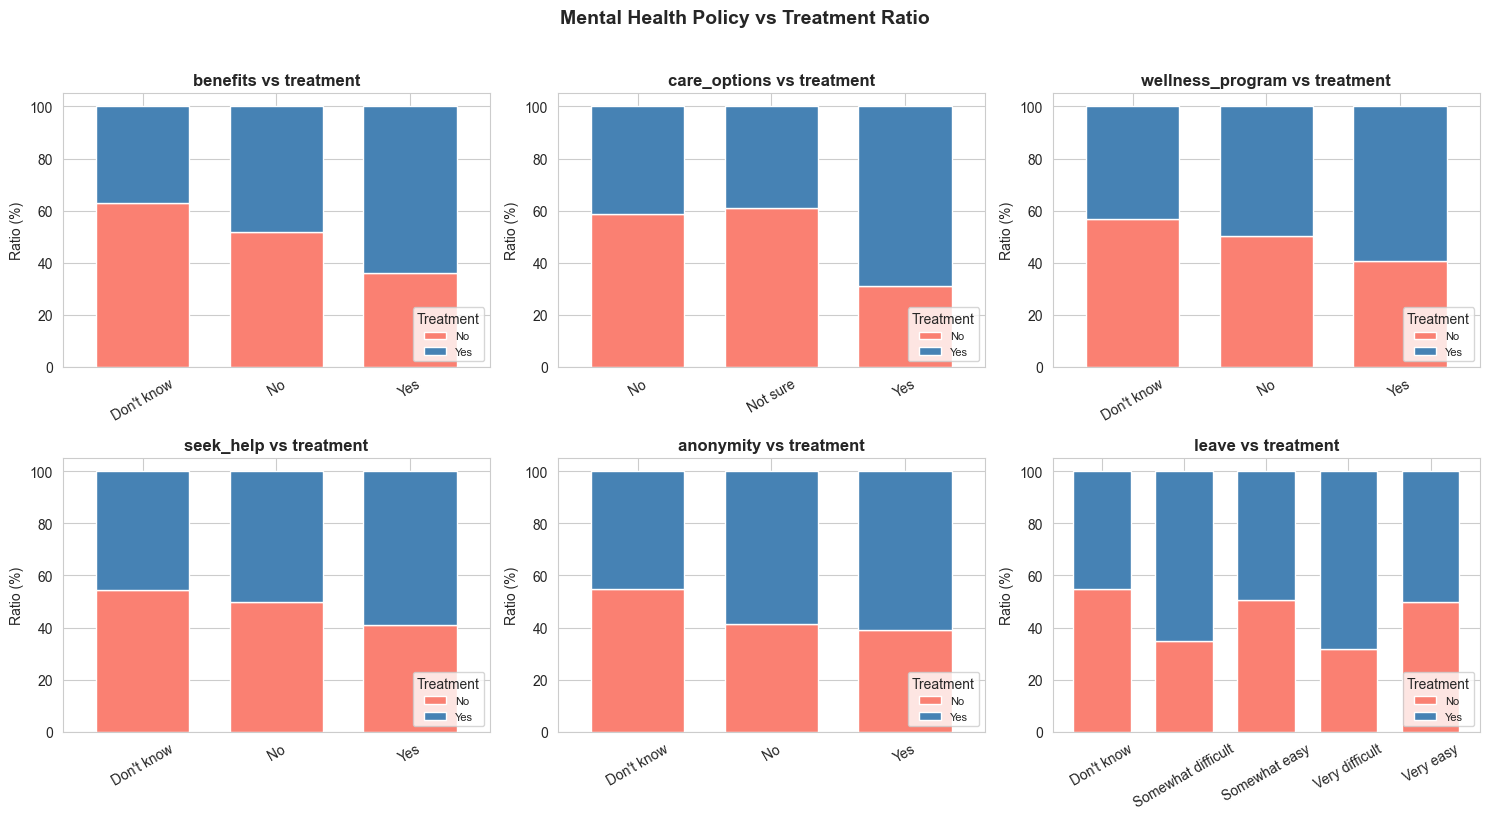

In [40]:
# Mental health policy variables vs treatment (stacked bar with normalized ratios)
policy_vars = ['benefits', 'care_options', 'wellness_program',
               'seek_help', 'anonymity', 'leave']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(policy_vars):
    # Normalize by row to get % treatment=Yes per category
    ct = pd.crosstab(df[col], df['treatment'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['salmon', 'steelblue'], width=0.7)
    axes[i].set_title(f'{col} vs treatment', fontweight='bold')
    axes[i].set_ylabel('Ratio (%)')
    axes[i].set_xlabel('')
    axes[i].legend(title='Treatment', loc='lower right', fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Mental Health Policy vs Treatment Ratio',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/policy_vs_treatment.png', dpi=100, bbox_inches='tight')
plt.show()

### 7-2. Workplace Atmosphere vs Treatment

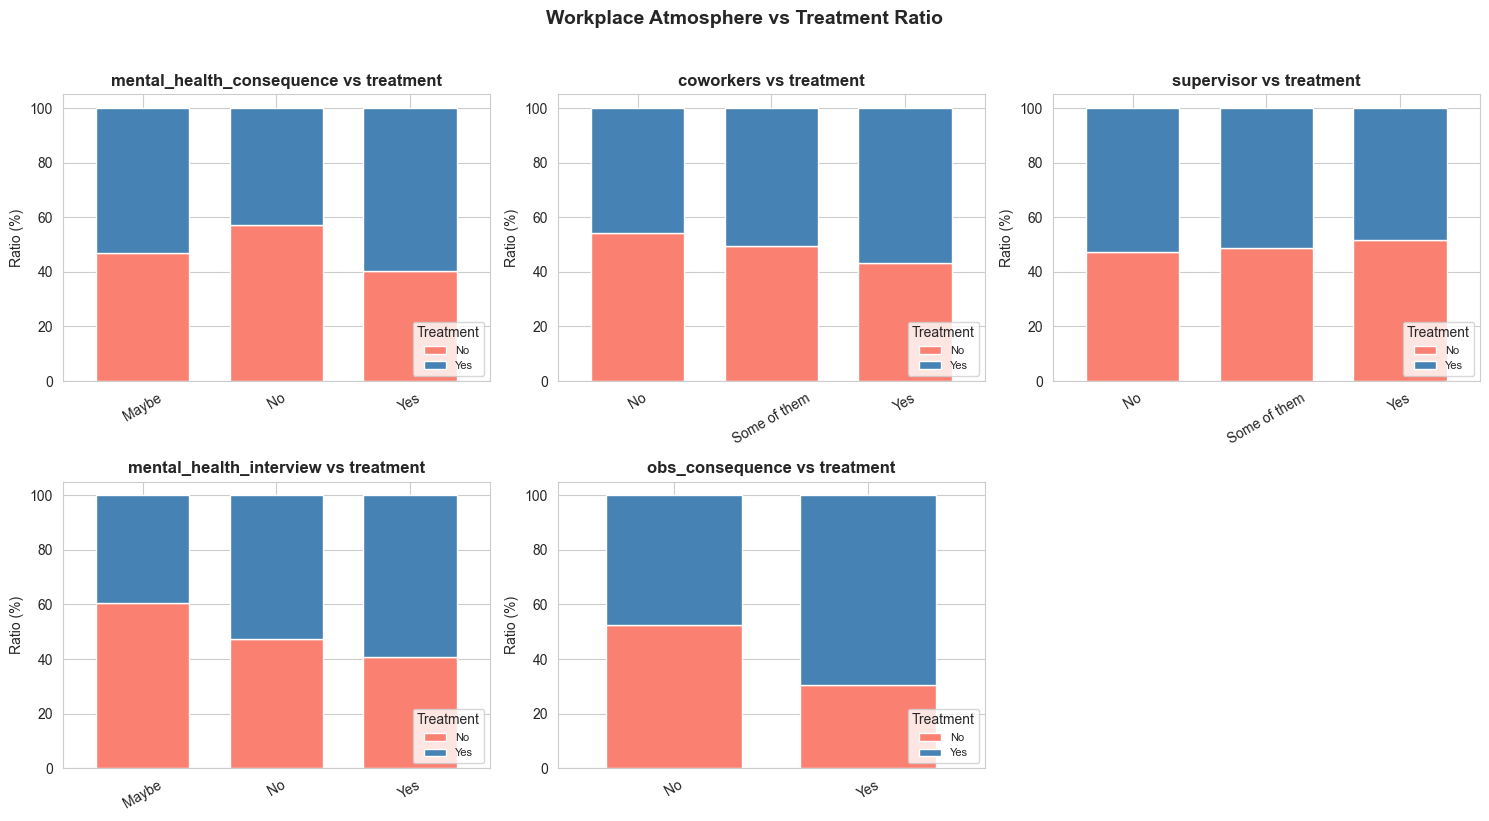

In [41]:
# Workplace atmosphere variables vs treatment
atmos_vars = ['mental_health_consequence', 'coworkers', 'supervisor',
              'mental_health_interview', 'obs_consequence']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(atmos_vars):
    ct = pd.crosstab(df[col], df['treatment'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['salmon', 'steelblue'], width=0.7)
    axes[i].set_title(f'{col} vs treatment', fontweight='bold')
    axes[i].set_ylabel('Ratio (%)')
    axes[i].set_xlabel('')
    axes[i].legend(title='Treatment', loc='lower right', fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

# Hide unused subplot
if len(atmos_vars) < 6:
    axes[-1].axis('off')

plt.suptitle('Workplace Atmosphere vs Treatment Ratio',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/atmosphere_vs_treatment.png', dpi=100, bbox_inches='tight')
plt.show()

### 7-3. Personal Factors vs Treatment

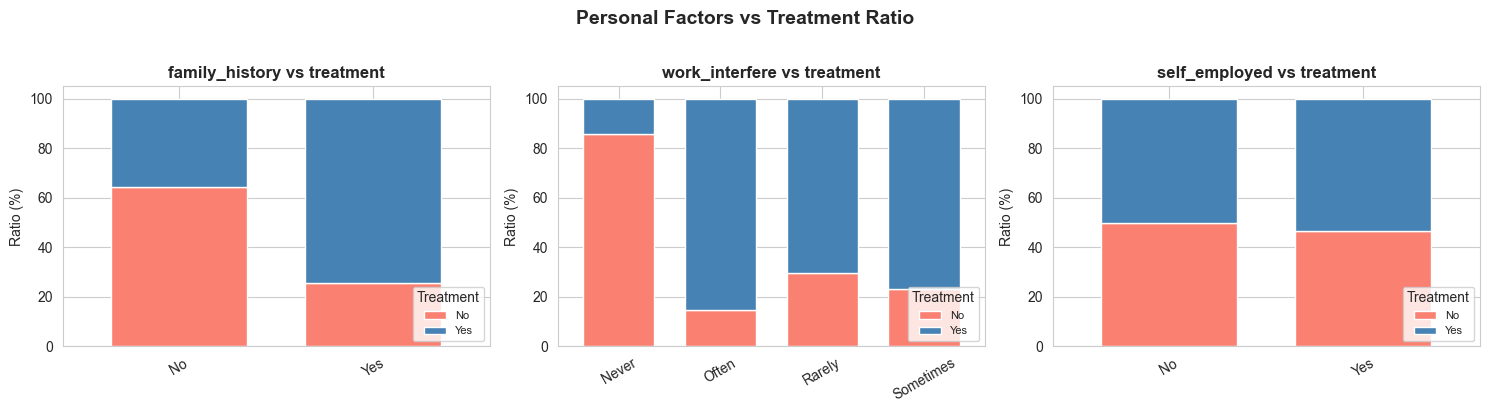

In [42]:
# Personal factor variables vs treatment (as control group)
personal_vars = ['family_history', 'work_interfere', 'self_employed']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(personal_vars):
    ct = pd.crosstab(df[col], df['treatment'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['salmon', 'steelblue'], width=0.7)
    axes[i].set_title(f'{col} vs treatment', fontweight='bold')
    axes[i].set_ylabel('Ratio (%)')
    axes[i].set_xlabel('')
    axes[i].legend(title='Treatment', loc='lower right', fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Personal Factors vs Treatment Ratio',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/personal_vs_treatment.png', dpi=100, bbox_inches='tight')
plt.show()

### 7-4. Age vs Treatment

ModuleNotFoundError: No module named 'scipy'

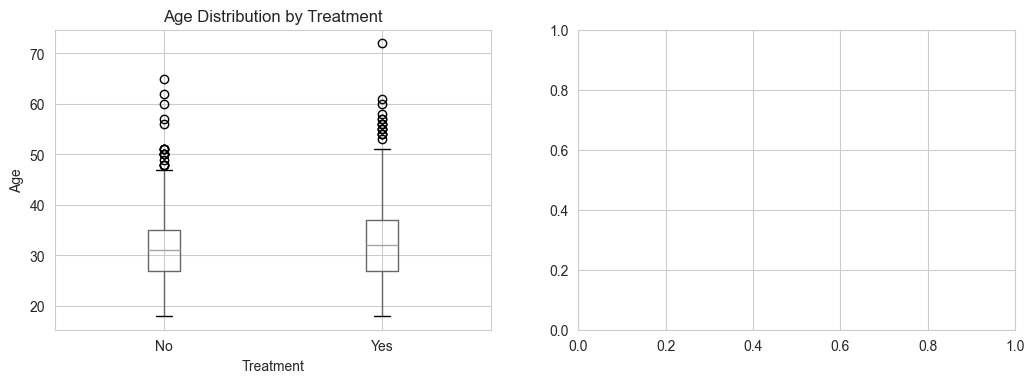

In [43]:
# Age vs treatment (filtered to reasonable range)
df_filtered = df[(df['Age'] >= 18) & (df['Age'] <= 75)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
df_filtered.boxplot(column='Age', by='treatment', ax=axes[0])
axes[0].set_title('Age Distribution by Treatment')
axes[0].set_xlabel('Treatment')
axes[0].set_ylabel('Age')
plt.suptitle('')

# KDE
for tr in ['Yes', 'No']:
    subset = df_filtered[df_filtered['treatment'] == tr]['Age']
    subset.plot(kind='kde', ax=axes[1], label=f'Treatment = {tr}')
axes[1].set_title('Age Distribution (KDE)', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/age_vs_treatment.png', dpi=100, bbox_inches='tight')
plt.show()

### 7-5. Gender vs Treatment (before normalization)

In [ ]:
# Gender (top 3) vs treatment, using raw data before normalization
top_gender = df['Gender'].value_counts().head(3).index.tolist()
df_g = df[df['Gender'].isin(top_gender)]

ct = pd.crosstab(df_g['Gender'], df_g['treatment'], normalize='index') * 100

plt.figure(figsize=(8, 4))
ct.plot(kind='bar', stacked=True, color=['salmon', 'steelblue'], width=0.6)
plt.title('Gender vs Treatment (top 3 raw values)', fontweight='bold')
plt.ylabel('Ratio (%)')
plt.xlabel('Gender')
plt.legend(title='Treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/gender_vs_treatment.png', dpi=100, bbox_inches='tight')
plt.show()